In [1]:
#Supplier Risk Analysis

In [8]:
# 1. Load and clean the data

In [30]:
import pandas as pd
from scipy import stats
import numpy as np
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
np.random.seed(42)

In [21]:
CSV_PATH = "supplier_order_history.csv"

In [24]:
try:
    df = pd.read_csv(CSV_PATH)
except FileNotFoundError:
    print(f"ERROR: could not find '{CSV_PATH}'.")
    print("Fix: change CSV_PATH above to the correct location of your file.")
    raise

print(f"Loaded {len(df)} rows across {df['Supplier'].nunique()} suppliers")


Loaded 1000 rows across 20 suppliers


In [32]:
metrics = ["Defect_Rate_PPM", "Lead_Time_Variance_Days", "Price_Volatility_Pct"]
suppliers = df["Supplier"].unique()
supplier_pos = {s: i for i, s in enumerate(suppliers)}  # x-position for each supplier

In [ ]:
# STEP 2: Basic cleanup

In [25]:
metrics = ["Defect_Rate_PPM", "Lead_Time_Variance_Days", "Price_Volatility_Pct"]

df = df.dropna(subset=["Supplier"] + metrics)   # remove incomplete rows
df = df.drop_duplicates()                        # remove duplicate rows

In [ ]:
# STEP 3: For each metric — is there a real difference between
# suppliers (ANOVA)? If so, which suppliers are the outliers (Tukey)?

In [26]:
ALPHA = 0.05

for metric in metrics:
    groups = [g[metric].values for _, g in df.groupby("Supplier")]
    f_stat, p_value = stats.f_oneway(*groups)

    print(f"\n--- {metric} ---")
    print(f"ANOVA: F = {f_stat:.2f}, p = {p_value:.6f}")

    if p_value >= ALPHA:
        print("No significant difference between suppliers.")
        continue

    tukey = pairwise_tukeyhsd(df[metric], df["Supplier"], alpha=ALPHA)
    pairs = pd.DataFrame(tukey._results_table.data[1:], columns=tukey._results_table.data[0])
    means = df.groupby("Supplier")[metric].mean()

    # Count how many peers each supplier is significantly worse than
    worse_count = {s: 0 for s in means.index}
    for _, row in pairs.iterrows():
        if row["reject"]:
            worse = row["group1"] if means[row["group1"]] > means[row["group2"]] else row["group2"]
            worse_count[worse] += 1

    flagged = {s: c for s, c in worse_count.items() if c > 0}
    if not flagged:
        print("No individual supplier stood out.")
        continue

    print("Flagged suppliers:")
    for supplier, count in sorted(flagged.items(), key=lambda x: -x[1]):
        print(f"  {supplier} — mean {means[supplier]:.2f}, worse than {count}/{len(means) - 1} suppliers")



--- Defect_Rate_PPM ---
ANOVA: F = 759.75, p = 0.000000
Flagged suppliers:
  Volt Precision Parts — mean 317.86, worse than 19/19 suppliers
  Apex Drivetrain Solutions — mean 183.17, worse than 18/19 suppliers

--- Lead_Time_Variance_Days ---
ANOVA: F = 233.71, p = 0.000000
Flagged suppliers:
  IronClad Metal Works — mean 15.23, worse than 19/19 suppliers
  Apex Drivetrain Solutions — mean 10.68, worse than 18/19 suppliers

--- Price_Volatility_Pct ---
ANOVA: F = 275.04, p = 0.000000
Flagged suppliers:
  Pinnacle Fasteners Co — mean 13.82, worse than 19/19 suppliers


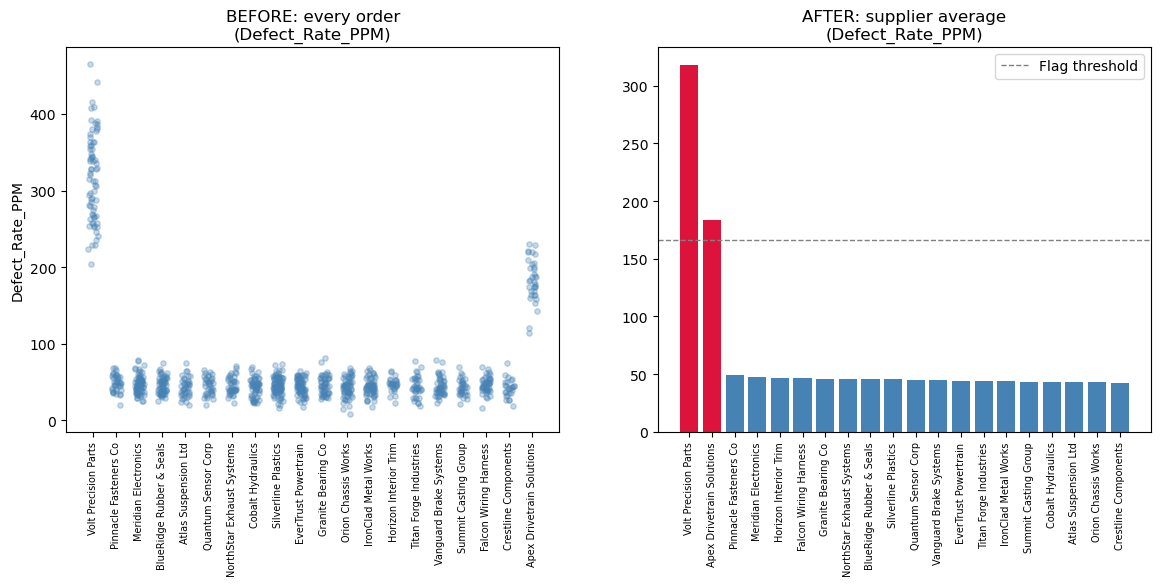

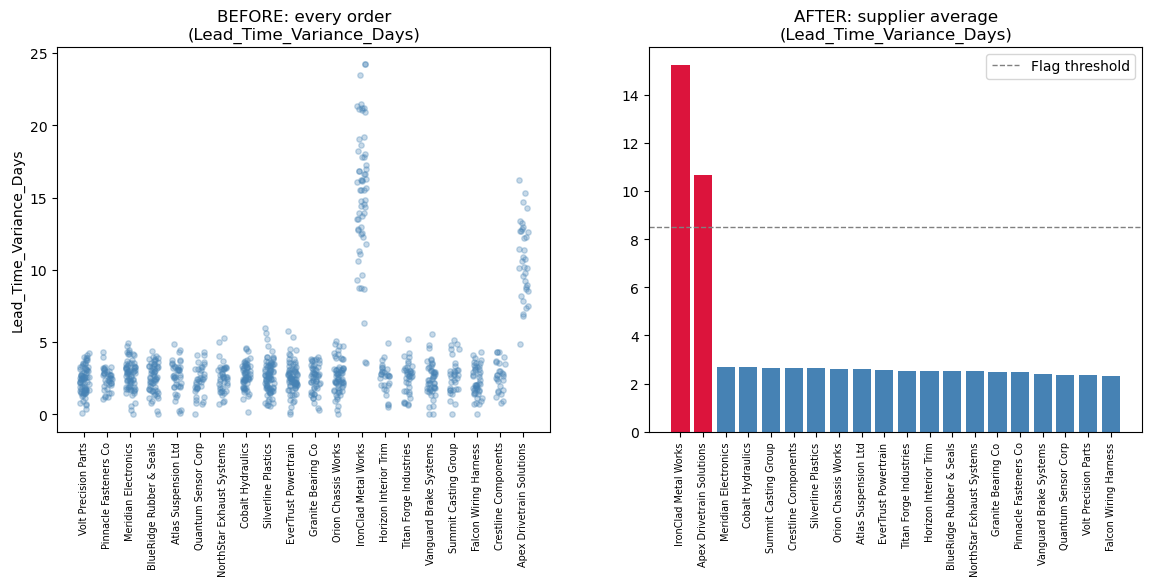

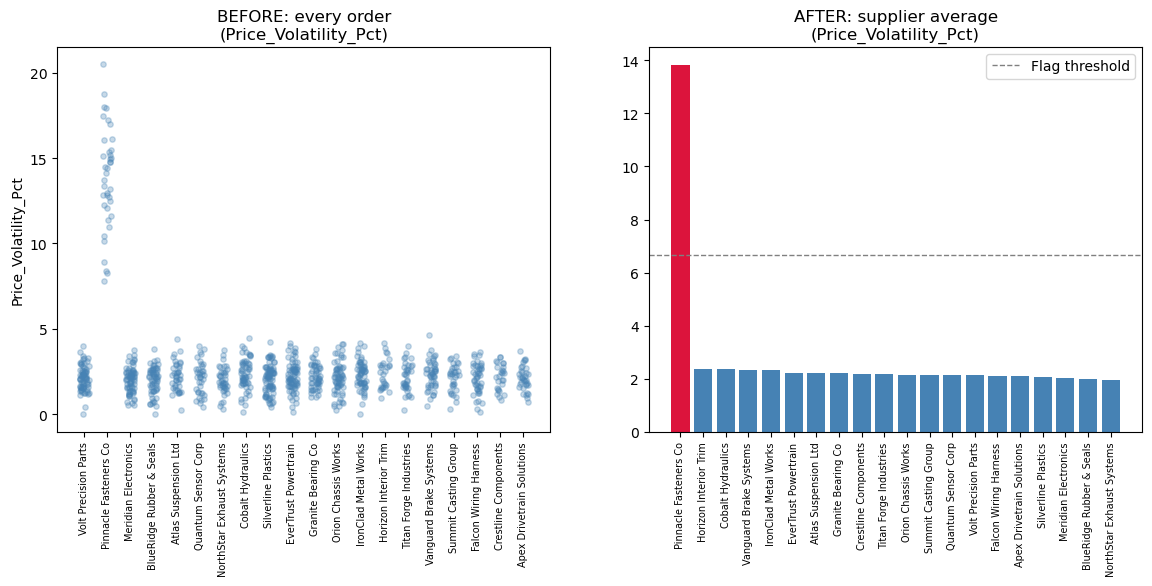

In [38]:
for metric in metrics:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ---- BEFORE: every individual order ----
    x_jitter = df["Supplier"].map(supplier_pos) + np.random.uniform(-0.2, 0.2, size=len(df))
    axes[0].scatter(x_jitter, df[metric], alpha=0.3, s=15, color="steelblue")
    axes[0].set_xticks(range(len(suppliers)))
    axes[0].set_xticklabels(suppliers, rotation=90, fontsize=7)
    axes[0].set_title(f"BEFORE: every order\n({metric})")
    axes[0].set_ylabel(metric)

    # ---- AFTER: one average per supplier ----
    supplier_avg = df.groupby("Supplier")[metric].mean().sort_values(ascending=False)

    # Flag any supplier sitting notably above the rest (mean + 1.5 std of the averages)
    threshold = supplier_avg.mean() + 1.5 * supplier_avg.std()
    colors = ["crimson" if v > threshold else "steelblue" for v in supplier_avg.values]

    axes[1].bar(range(len(supplier_avg)), supplier_avg.values, color=colors)
    axes[1].set_xticks(range(len(supplier_avg)))
    axes[1].set_xticklabels(supplier_avg.index, rotation=90, fontsize=7)
    axes[1].axhline(threshold, color="gray", linestyle="--", linewidth=1, label="Flag threshold")
    axes[1].set_title(f"AFTER: supplier average\n({metric})")
    axes[1].legend()
